# Molecular prediction of both axes

The heads of both axes are compared on the classes they share, and the wide head on the classes only it has (extension range), to see whether widening the axis changes the prediction of the common molecules and whether the new molecules are learned.

## Introduction

Per-class metrics are paired by class and repetition index for the 508 common classes. Classes of the extension
range exist only on the wide head; they are summarised as a class set. METASPACE agreement of the probability
maps is compared per image and common class.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* Both axes are evaluated on identical pixels (same source spectra), so per-pixel comparisons are paired. The
  models of the two axes are independent; repetition $r$ of one axis is paired with repetition $r$ of the other only
  for convenience (the seeds are equal but the models are not related).
* Global $W_1$ values are not comparable across axes: the wide axis transports intensity over a longer m/z range and
  normalizes by a TIC that includes the extension. Comparisons of reconstruction therefore use the windows shared by
  both axes, where the within-window cost is renormalized and comparable.

        * Rankings use the ranking population `annotation_retrieval` unless stated; evaluations `test_combined` (test and
          rare-class extension) and `heldout_image`.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Narrow axis $\mathcal{A}_n$ = 200-900 m/z (1273 bins); wide axis $\mathcal{A}_w$ = 100-3000 m/z (5273 bins); common
  windows = 200-300, ..., 800-900; extension windows = 100-200 and 900-3000.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "axis_comparison_prediction"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
NARROW, WIDE = metadata.get('narrow_axis', 'axis-200-900'), metadata.get('wide_axis', 'axis-100-3000')
AXIS_LABELS = {axis: catalog[catalog.axis == axis].display_label.iloc[0] for axis in (NARROW, WIDE)}
AXIS_COLORS = {axis: LABEL_COLORS[AXIS_LABELS[axis]] for axis in (NARROW, WIDE)}
DATASETS = sorted(load_table(settings, 'axis_comparison_reconstruction', 'image_maps').dataset_id.unique())
print('Narrow axis:', NARROW, '| wide axis:', WIDE, '| held-out images:', DATASETS)

pairs = table('common_class_pairs')
EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']

Analysis: axis_comparison_prediction | axis: None | models: 10
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Narrow axis: axis-200-900 | wide axis: axis-100-3000 | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`axis_comparison_prediction` pairs the per-class ranking tables of both axes and recomputes METASPACE agreement with the function of `part_1_11`.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis axis_comparison_prediction > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis          repetition model_id                                                                                                                                                      
axis-100-3000 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7052  0.5102       4.0381                   0.8771          1.0991        3.2           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6942  0.5129       4.0117                   0.8824          1.0917        2.0            True
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6851  0.4777       3.7285                   0.8647          1.0539        3.4           False
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7068  0.5122       4.0129                   0.8813          1.1247        2.8           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6951  0.5102       4.1471                   0.8816          1.1029        3.6           False
axis-200-900  0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Probability maps of repetition 2 (200-900) and repetition 1 (100-3000).

### Notes

## Common classes: AP of both axes

### Methodology

#### Theoretical

For every common class the repetition-mean AP of both axes; the paired difference per class and repetition shows
whether widening the axis helps or hurts the shared molecules.

#### Implementation

`common_class_pairs` rows of eligible classes on both axes.

#### Figure descriptions

Scatter: x = AP narrow, y = AP wide (repetition means), diagonal = equality; colour = evaluation. Table: mean and
median paired difference per evaluation.

,count,mean,50%,std
evaluation,,,,
heldout_image,85.0,1.6511e-02,1.0847e-02,0.0661
test,2540.0,-4.1795e-03,-2.7240e-05,0.0917
test_combined,2540.0,-3.9708e-03,-4.6570e-05,0.0599
test_extended,2215.0,-9.8159e-05,0.0000e+00,0.0633
train,2540.0,-3.5712e-03,-4.9570e-05,0.0550


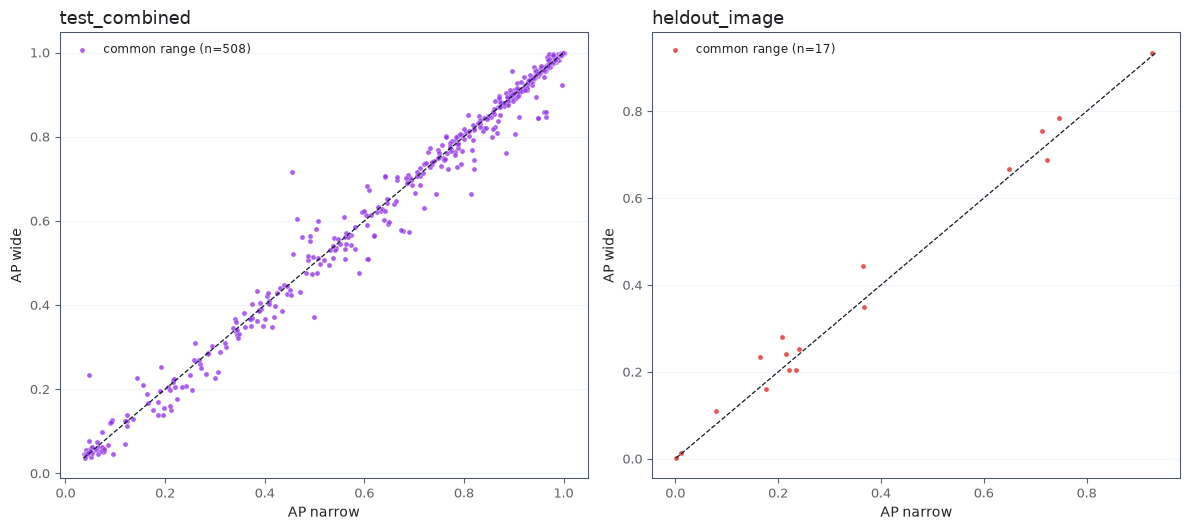

In [4]:
shown = pairs[(pairs.population == 'annotation_retrieval') & pairs.eligible_narrow.astype(bool) & pairs.eligible_wide.astype(bool)]
means = shown.groupby(['evaluation', 'class_name'], as_index=False)[['average_precision_narrow', 'average_precision_wide']].mean()
figure, axes = plt.subplots(1, 2, figsize=(12, 5.4), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    figures.paired_scatter(means[means.evaluation == evaluation].assign(set='common'), x='average_precision_narrow', y='average_precision_wide', hue='set', hue_order=['common'], xlabel='AP narrow', ylabel='AP wide', title=evaluation, ax=ax, colors={'common': POPULATION_COLORS[evaluation]}, theme=theme)
figure.tight_layout()
display(shown.groupby('evaluation').ap_difference.describe()[['count', 'mean', '50%', 'std']])

### Remarks

- Paired AP differences of common classes are centred on zero on train/test (mean -0.004, SD 0.06-0.09); on held-out images the wide head is better for 71 % of the 85 eligible class-image pairs (mean +0.017).

### Notes

## Macro metrics per class set and axis

### Methodology

#### Theoretical

Macro AP, ROC AUC and micro recall per class set show how the extension classes compare with the common ones.

#### Implementation

`class_set_summary` (strata metrics by class set, both axes).

#### Figure descriptions

x = class set, colour = axis, one point per repetition; panels = evaluations.

average_precision              eligible_classes             
axis                        axis-100-3000 axis-200-900    axis-100-3000 axis-200-900
evaluation    stratum                                                               
heldout_image common               0.3722       0.3557             17.0         17.0
              extension            0.3981          NaN              3.0          NaN
test          common               0.6911       0.6953            508.0        508.0
              extension            0.7579          NaN             52.0          NaN
test_combined common               0.7048       0.7088            508.0        508.0
              extension            0.7411          NaN             55.0          NaN
test_extended common               0.7083       0.7084            443.0        443.0
              extension            0.7766          NaN             49.0          NaN
train         common               0.6729       0.6764            508.0        508.0
              extension            0.7045          NaN             55.0          NaN

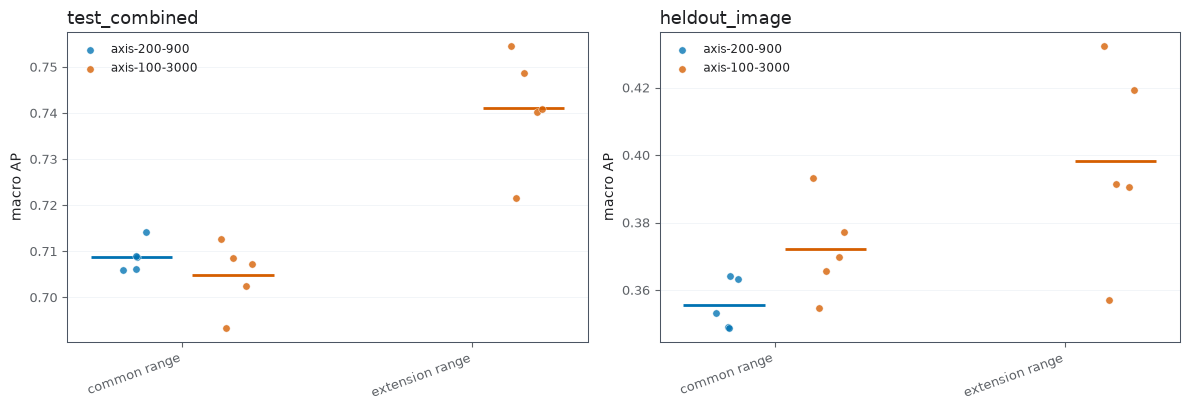

In [5]:
summary_frame = table('class_set_summary')
summary_frame = summary_frame[(summary_frame.group == 'all') & (summary_frame.population == 'annotation_retrieval')]
sets = [value for value in figures.CLASS_SET_ORDER if value in set(summary_frame.stratum)]
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    figures.repetition_points(summary_frame[summary_frame.evaluation == evaluation], value='average_precision', group='stratum', hue='axis', order=sets, hue_order=[NARROW, WIDE], colors=AXIS_COLORS, ylabel='macro AP', title=evaluation, ax=ax, theme=theme)
figure.tight_layout()
display(summary_frame.pivot_table(index=['evaluation', 'stratum'], columns='axis', values=['average_precision', 'eligible_classes'], aggfunc='mean'))

### Remarks

- Wide axis: extension classes 0.74 vs common 0.71 macro AP (test + extension); held-out 0.40 vs 0.37.

### Notes

## METASPACE agreement of both axes

### Methodology

#### Theoretical

Per image and common class, the METASPACE Spearman of both heads' probability maps.

#### Implementation

`agreement_pairs` (repetition-paired).

#### Figure descriptions

x = narrow Spearman, y = wide Spearman (repetition means), diagonal = equality; colour = image.

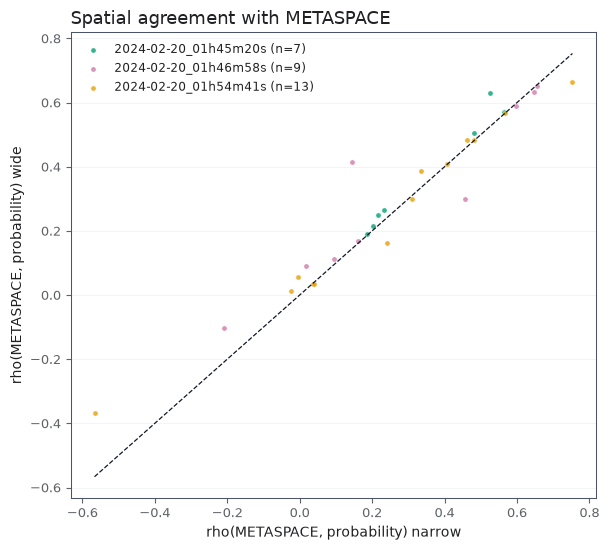

In [6]:
agreement = table('agreement_pairs').groupby(['dataset_id', 'class_name'], as_index=False)[['spearman_narrow', 'spearman_wide']].mean()
figures.paired_scatter(agreement, x='spearman_narrow', y='spearman_wide', hue='dataset_id', hue_order=DATASETS, xlabel='rho(METASPACE, probability) narrow', ylabel='rho(METASPACE, probability) wide', title='Spatial agreement with METASPACE', colors={dataset: theme.model_palette[position + 2] for position, dataset in enumerate(DATASETS)}, theme=theme);

### Remarks

- METASPACE Spearman of common classes is higher on the wide axis for 66 % of image-class pairs (mean 0.30 vs 0.28).

### Notes

## Probability maps of both axes for selected classes

### Methodology

#### Theoretical

The classes selected on the narrow axis are shown next to their METASPACE image with both heads' probability maps.

#### Implementation

`ion_image_pairs` (probabilities of the representative model of each axis).

#### Figure descriptions

Rows = image-class pairs, columns = METASPACE intensity, annotation target (METASPACE > 0), narrow probability,
wide probability; own colour range per panel, METASPACE and target ranges from their positive pixels. The
probabilities are to be read against the target: the target is positive wherever METASPACE has any non-zero
intensity, even where the ion image looks dark.

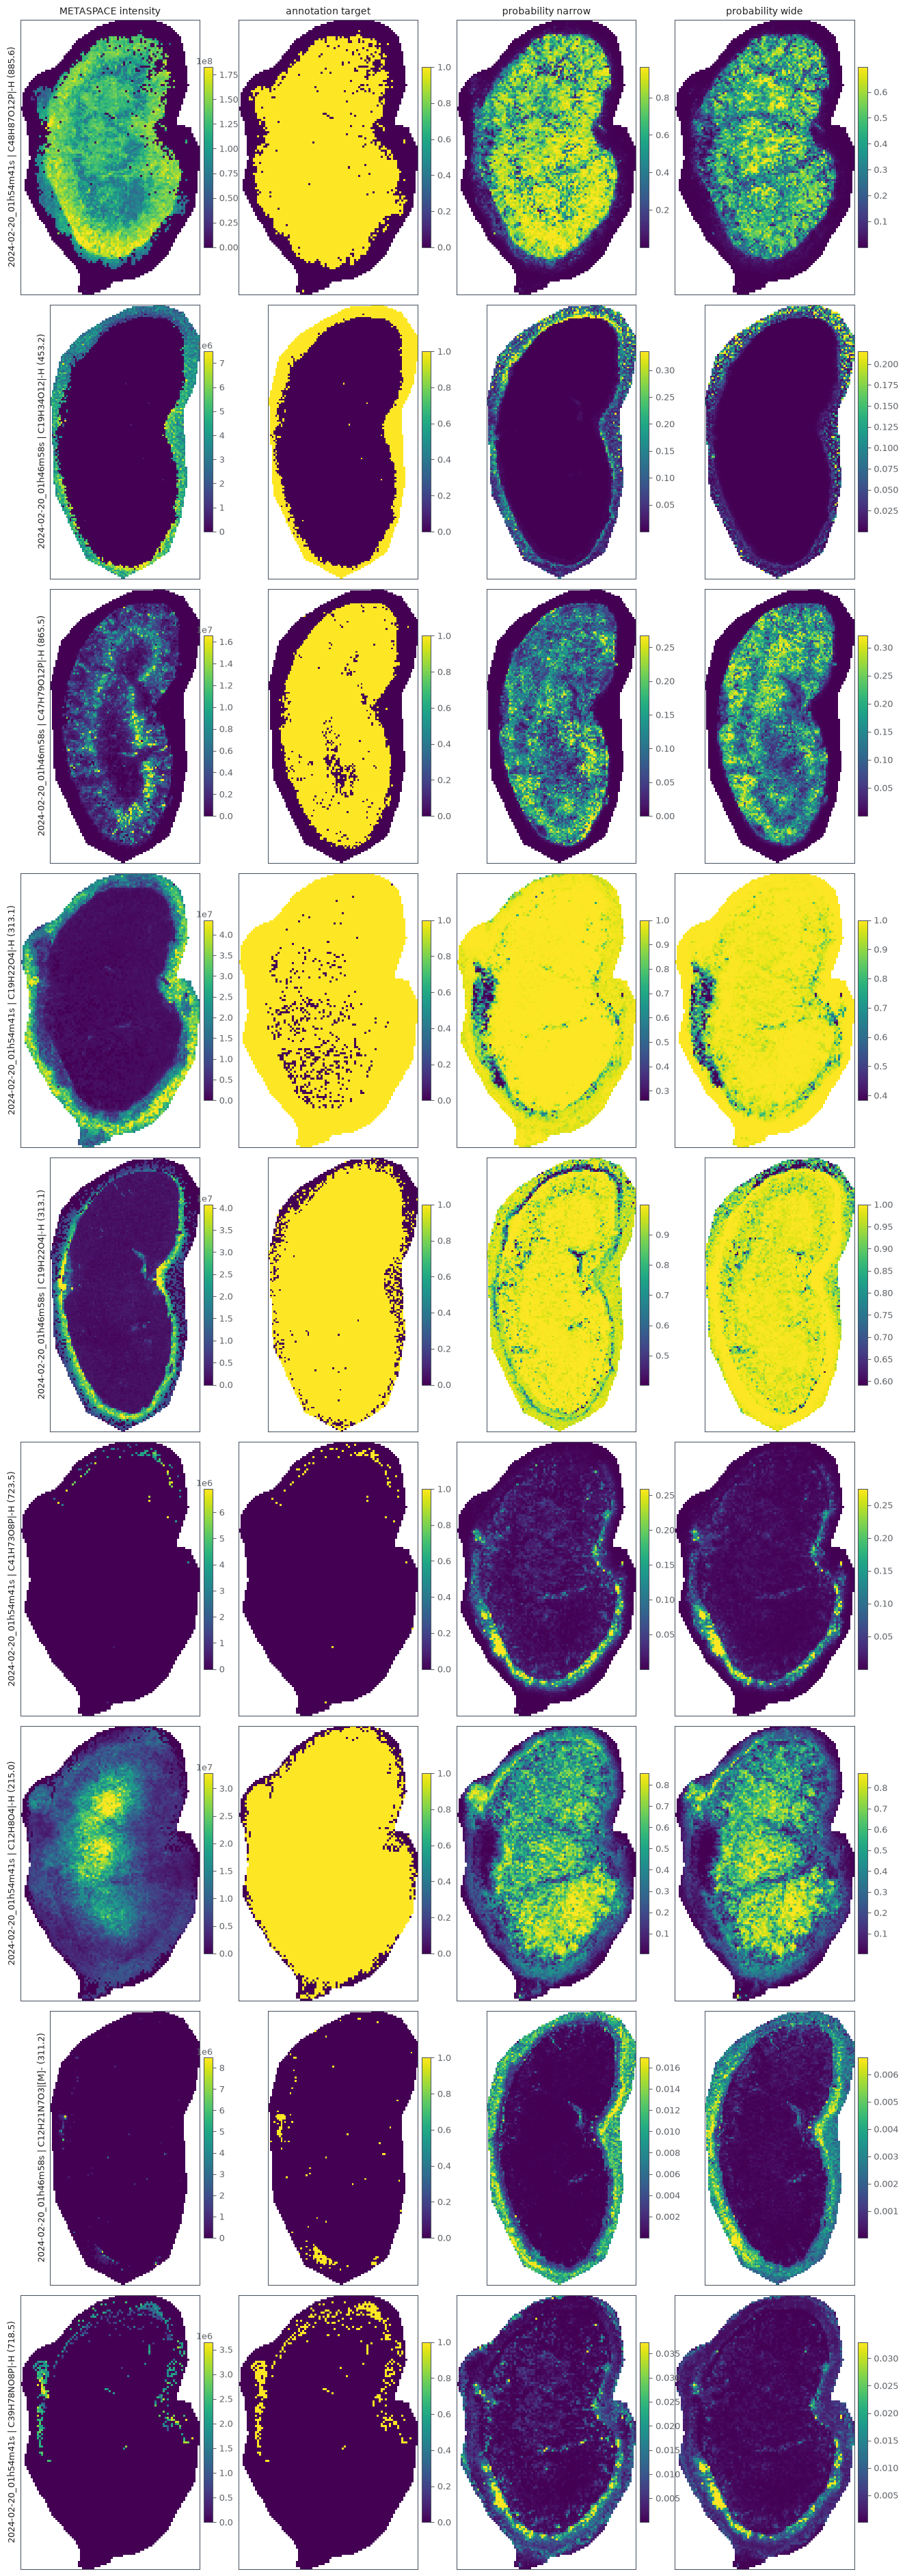

In [7]:
maps = table('ion_image_pairs')
maps['panel'] = maps.dataset_id + ' | ' + maps.class_name + ' (' + maps.mz.round(1).astype(str) + ')'
rows = list(dict.fromkeys(maps.panel))
figures.image_panels(maps, value_columns=['metaspace', 'target', 'probability_narrow', 'probability_wide'], column_titles=['METASPACE intensity', 'annotation target', 'probability narrow', 'probability wide'], datasets=rows, row_column='panel', shared_scale='panel', positive_columns=['metaspace', 'target'], cmap=theme.probability_colormap, theme=theme);

### Remarks

- Both heads produce the same spatial maps for common classes (Spearman between the probability maps 0.87-0.95), while the level differs by class: C48H87O12P|-H 0.67 (narrow) versus 0.37 (wide) on target, C47H79O12P|-H 0.11 versus 0.16.
- C19H22O4|-H is predicted at about 0.95 over the whole tissue by both heads, in agreement with its target (about 90 % of the pixels), not with the border-localized METASPACE intensity.

### Notes

## Results / Summary

### LLM

- **Observed:** on the common classes both heads predict equally well on seen images; on new images the wide head is slightly better (AP +0.017 on average, better for 71 % of pairs; METASPACE agreement 0.30 vs 0.28).
- **Observed:** the extension classes are learned at least as well as the common ones.
- **Interpretation:** for molecular prediction the wide axis costs nothing on common molecules and adds 55 detectable classes; the image-level generalization failure is shared by both axes.

### Person